# Sequence Alignment

Sequence aligment is a fancy way of saying sequence comparison, since it determines the **similarity** of two sequences, by computing its distance or score.

The **sequence aligment recipe** to be able to perform one is the follwing:

**EDIT OPERATIONS**

- **Match (M)** - two characters are equal
- **Mismatch (X)** - change one character for another
- **Insertion (I)** - add a new character
- **Deletion (D)** - remove an existing character


**DISTANCE FUNCTION**

- It is the cost associated with each one of the transformations. The cost provided by the distance function gives the *similarity* between the sequences.

Sequence alignment is fundamentally a **cost minimization problem**, where we aim to transform one sequence into another using the least expensive combination of edit operations. This is where dynamic programming algorithms, like **Needleman-Wunsch and Smith-Waterman**, come into play.


---
## Combinatorial search apporach 

Use the combinatorial search approach to find the edit-distance between two stings, in this case, between `BAR`and `BADA`. Remember that:

Using the **sequence aligment recipe** and considering that **pattern** is the first sequence and **text** is the second sequence.

We want to convert pattern into text minimizing a distance function. 
>In the edit-distance case, a match has a cost of 0, and other operations has a cost of 1 ($\{M,X,I,D\} = \{0,1,1,1\}$)



In [1]:
def edit_distance(pattern, text):
    # Recursion base bases
    if len(pattern) == 0:
        distance = len(text)
        return (distance, 'I'*distance)
        
    elif len(text) == 0:
        distance = len(pattern)
        return (distance, 'D'*distance)
        
    else:
        # Match or mismatch
        if pattern[0] == text[0]:
            # Match
            m_cost, m_cigar = edit_distance(pattern[1:], text[1:])
        else:
            # Mismatch
            m_cost, m_cigar = edit_distance(pattern[1:], text[1:])
            m_cost += 1
            
        # Find score for insertion
        i_cost, i_cigar = edit_distance(pattern[:],text[1:])
        i_cost += 1
        # Find score for deletion
        d_cost, d_cigar = edit_distance(pattern[1:],text[:])
        d_cost += 1
        # Find the minimum combination
        min_cost = min(m_cost,i_cost,d_cost)
        if min_cost == m_cost:
            if pattern[0] == text[0]:
                return (m_cost, 'M' + m_cigar)
            else:
                return (m_cost, 'X' + m_cigar)
                
        elif min_cost == i_cost:
            return (i_cost, 'I' + i_cigar)
        else:
            return (d_cost, 'D' + d_cigar)


pattern = "BAR"
text = "BADA"
distance, cigar = edit_distance(pattern, text)
print(f'The distance between {pattern} and {text} is: {distance}')
print(f'The CIGAR is: {cigar}')

The distance between BAR and BADA is: 2
The CIGAR is: MMXI


---
### Memoization

Even though this is a good way to compute a sequence alignment, the number of recursive calls is very high (897625) since we compute things already solved. To solve this issue, we can use memoization.

The key idea is to memorize all the partial results that we explore, so if the partial result has already been explored, we return the saved value (instead of solving it again).

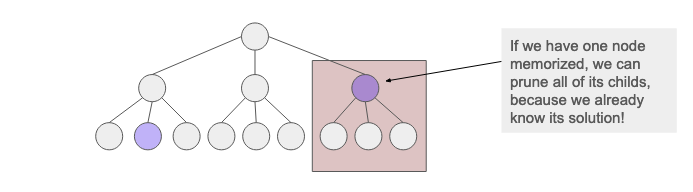


In [2]:
num_calls = 0
saved_calls = {}

def edit_distance(pattern, text):
    global num_calls
    global saved_calls
    
    num_calls += 1
    
    # Check if we already computed the current value
    key = pattern + ':' + text
    if key in saved_calls:
        return saved_calls[key]

    # Recursion base bases
    if len(pattern) == 0:
        return len(text)
        
    elif len(text) == 0:
        return len(pattern)
        
    else:
        # Match or mismatch
        if pattern[0] == text[0]:
            # Match
            m_cost = edit_distance(pattern[1:], text[1:])
        else:
            # Mismatch
            m_cost = edit_distance(pattern[1:], text[1:]) + 1
            
        # Find score for insertion
        i_cost = edit_distance(pattern[:],text[1:]) + 1
        # Find score for deletion
        d_cost = edit_distance(pattern[1:],text[:]) + 1
        # Find the minimum combination
        
        # Save the currently computed partial result
        key = pattern + ':' + text
        saved_calls[key] = min(m_cost,i_cost,d_cost)
        
        return min(m_cost,i_cost,d_cost)


pattern = "BARCELONA"
text = "BADALONA"
distance = edit_distance(pattern, text)
print(f'The distance between {pattern} and {text} is: {distance}')
print(f'The number of calls performed is: {num_calls}')

The distance between BARCELONA and BADALONA is: 3
The number of calls performed is: 217


---
## Dynamic Programming approach

The dynamic programming approach solves the sequence aligment problem in an efficient way by sistematically computing the aligment costs for all prefixes of the sequences. The results of these computations are stored in a table (the **alignment matrix "M"**). Each cell of ***M_{i,j}*** of this matrix represents the cost of aligning the first 
***i*** characters of a sequence *A* with the first ***j*** characters of a sequence ***B***.

The value of **`M_{i,j}`** is computed based on three possible operations:

- **Match/Mismatch:** Extending the alignment by comparing the characters A[i] and B[j].
- **Insertion:** Adding a gap in sequence A.
- **Deletion:** Adding a gap in sequence B.

The recurrence relation is:
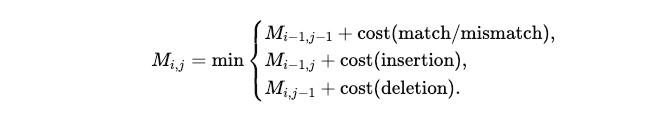

We can either use the ***Needleman-Wunsch Algorithm*** or the ***Smith-Waterman Algorithm***, both explained in detail below.


---
### Needleman-Wunsch Algorithm

The Needleman-Wunsch algorithm is a global alignment algorithm designed to align two sequences end-to-end. It is best suited for cases where the sequences are expected to have comparable lengths and alignment across their entire lengths is meaningful.

Key features:

- **Initialization:** The first row and column of the matrix are initialized based on gap penalties, reflecting the cost of aligning a sequence entirely with gaps.
- **Scoring:** Matches are rewarded (low cost), and mismatches or gaps incur penalties (higher cost).
- **Traceback**: After filling the matrix, the optimal alignment path is traced back from the bottom-right corner to reconstruct the alignment.




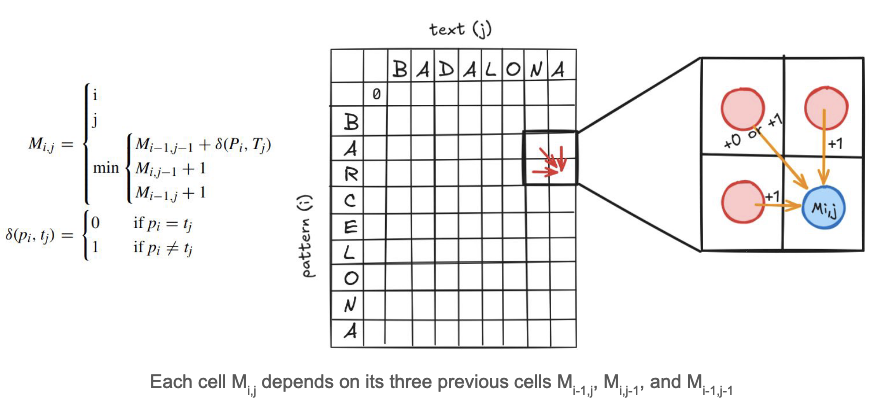

According to this algorithm, we are will create a script that builds and fills a dynamic programming (DP) matrix to calculate the edit distance, then performs a backtrace to reconstruct the alignment.

>we use `matplotlib`, for the better visualization of the final matrix.


The distance between THEO and TEO is: 1
The cigar is: MDMM
Backtrace path: [(0, 0), (1, 1), (2, 1), (3, 2), (4, 3)]


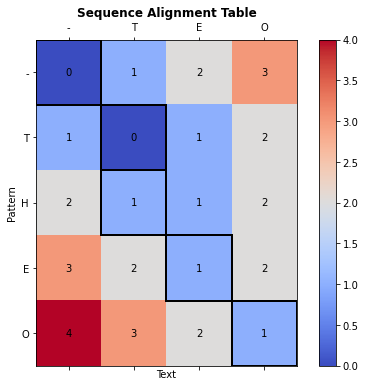

In [5]:
# NEEDLEMAN-WUNSCH ALGORITHM

import numpy as np
import matplotlib.pyplot as plt

# Function to compute the DP matrix
def edit_distance_dp(pattern, text):
    # Initialize the DP Matrix (M)
    m = len(pattern)
    n = len(text)
    M = [[0] * (n + 1) for _ in range(m + 1)]

    # Initialize the first column and row
    for i in range(m + 1):
        M[i][0] = i
    for j in range(n + 1):
        M[0][j] = j


    # Fill the rest of the DP matrix
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if pattern[i - 1] == text[j - 1]:
                num = 0  # No penalty for match
            else:
                num = 1  # Penalty for mismatch

            insertion = M[i - 1][j]
            deletion = M[i][j - 1]
            mismatch_match = M[i - 1][j - 1]

            M[i][j] = min(insertion + 1, deletion + 1, mismatch_match + num)

    distance, cigar, backtrace_path = backtrace_dp(M, pattern, text)
    return M, (distance, cigar, backtrace_path)

# Function to backtrace the DP matrix
def backtrace_dp(M, pattern, text):
    v = len(pattern)
    h = len(text)

    cigar = ''
    distance = M[v][h]
    backtrace_path = [(v, h)]  # Start at the bottom-right corner

    while v > 0 and h > 0:
        if M[v][h] == M[v - 1][h] + 1:  # Deletion
            cigar = 'D' + cigar
            v -= 1
        elif M[v][h] == M[v][h - 1] + 1:  # Insertion
            cigar = 'I' + cigar
            h -= 1
        else:  # Match or Mismatch
            if pattern[v - 1] == text[h - 1]:
                cigar = 'M' + cigar  # Match
            else:
                cigar = 'X' + cigar  # Mismatch
            v -= 1
            h -= 1
        backtrace_path.append((v, h))

    # Handle remaining borders
    while v > 0:
        cigar = 'D' + cigar
        v -= 1
        backtrace_path.append((v, h))
    while h > 0:
        cigar = 'I' + cigar
        h -= 1
        backtrace_path.append((v, h))

    backtrace_path.reverse()  # Reverse to start from the top-left
    return distance, cigar, backtrace_path

# Function to visualize the alignment table = heatmap
def visualize_alignment_table(M, pattern, text, backtrace_path):
    fig, ax = plt.subplots(figsize=(8, 6))

    cax = ax.matshow(M, cmap="coolwarm")
    plt.colorbar(cax)

    ax.set_xticks(np.arange(len(text) + 1))
    ax.set_yticks(np.arange(len(pattern) + 1))
    ax.set_xticklabels(['-'] + list(text))
    ax.set_yticklabels(['-'] + list(pattern))

    # Annotate each cell with the alignment score
    for i in range(len(pattern) + 1):
        for j in range(len(text) + 1):
            ax.text(j, i, str(M[i][j]), ha='center', va='center', color='black')

    # Highlight the backtrace path with blue outlines
    for (i, j) in backtrace_path:
        rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, edgecolor='black', fill=False, linewidth=2)
        ax.add_patch(rect)

    # Set title and labels
    plt.title("Sequence Alignment Table", weight="bold")
    plt.xlabel("Text")
    plt.ylabel("Pattern")
    plt.show()

# Main script
if __name__ == "__main__":
    pattern = "THEO"
    text = "TEO"

    # Compute the DP matrix and backtrace
    M, (distance, cigar, backtrace_path) = edit_distance_dp(pattern, text)

    print(f'The distance between {pattern} and {text} is: {distance}')
    print(f'The cigar is: {cigar}')
    print(f'Backtrace path: {backtrace_path}')

    # Visualize the alignment table with the backtrace highlighted
    visualize_alignment_table(M, pattern, text, backtrace_path)


---
### Smith-Waterman Algorithm

The Smith-Waterman algorithm performs local sequence aligment, that is, for determining similar regions between two strings of nucelic acid sequences or proteins. Instead of looking at the entire sequence the algorithm **compares segments of all possible lenghts and optimizes the similarity measure**.

Similarly to the Needleman-Wunsch algorithm, it has these key features:

- **Determine the substitution matrix and gap penalty scheme**: A substitution matrix assigns each pair of bases or amino acids a score for match or mismatch. Usually matches get positive scores, whereas mismatches get relatively lower scores. A **gap penalty function** determines the score cost for opening or extending gaps.
- **Initialize the scoring matrix**: dimensions of the scoring matrix are 1+length of each sequence respectively.All the elements of the first row and the first column are set to 0. The extra first row and first column make it possible to align one sequence to another at any position, and setting them to 0 makes the terminal gap free from penalty.
- **Scoring**: Score each element from left to right, top to bottom in the matrix, considering the outcomes of substitutions (diagonal scores) or adding gaps (horizontal and vertical scores). If none of the scores are positive, this element gets a 0. Otherwise the highest score is used and the source of that score is recorded.
- **Traceback**: Starting at the element with the highest score, traceback based on the source of each score recursively, until 0 is encountered. The segments that have the highest similarity score based on the given scoring system is generated in this process. To obtain the second best local alignment, apply the traceback process starting at the second highest score outside the trace of the best alignment.

Here's the equation of the scoring system:

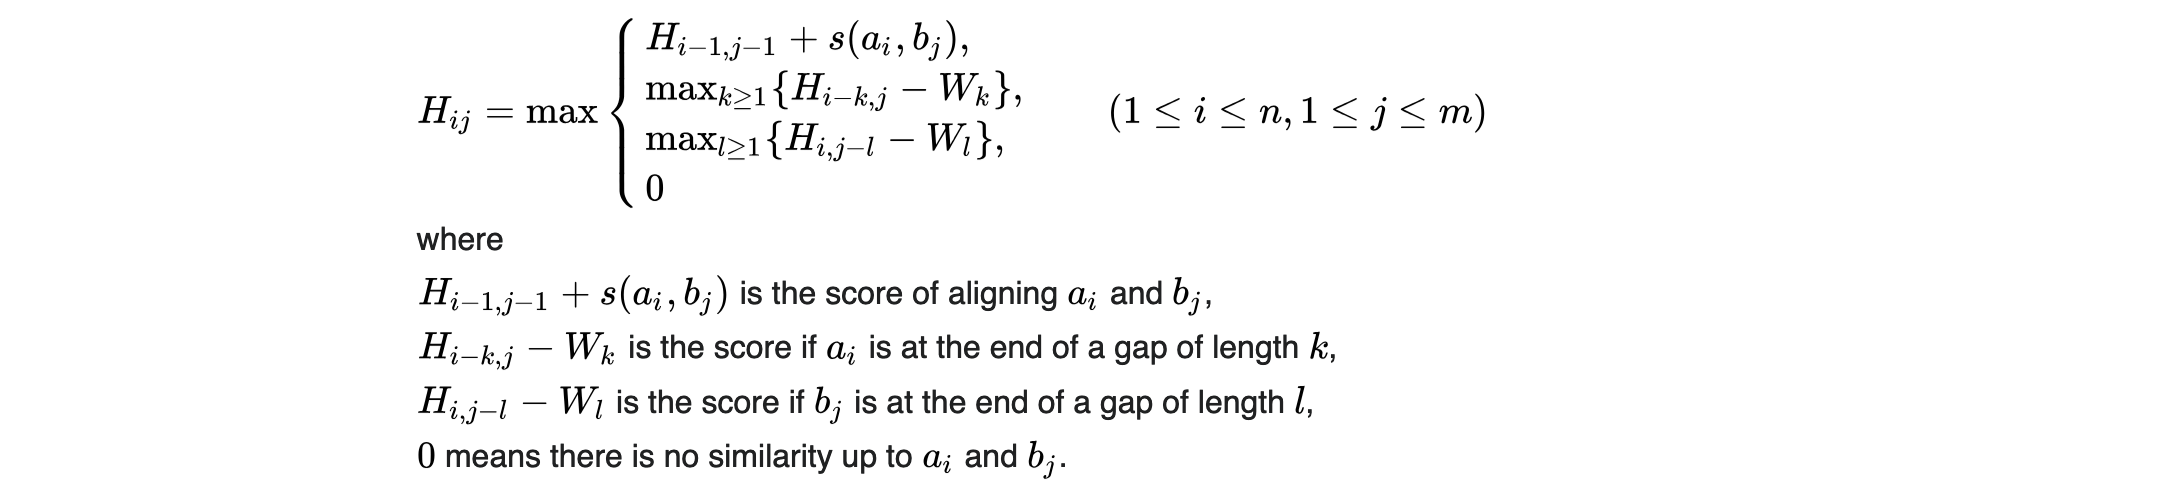

In [2]:
# SMITH-WATERMAN SEQUENCE ALIGNMENT ALGORITHM

def pprint_matrix(M, pattern, text):
    try:
        if (len(pattern) + 1 != len(M)) or (len(text) + 1 != len(M[0])):
            raise Exception('Invalid matrix dimensions')
        # Print the header row
        print('    ', end='')
        for idx in range(len(text)):
            print(text[idx], end=' ')
        print()

        # Print each row
        for ridx, row in enumerate(M):
            for cidx in range(len(row)):
                if cidx == 0:
                    # Print the pattern character for the row
                    print(' ' if ridx == 0 else pattern[ridx - 1], end=' ')
                print(M[ridx][cidx], end=' ')
            print()
    except Exception as e:
        print(f'Invalid dynamic programming matrix! Are you sure you are creating the matrix with the correct dimensions?')
        raise e

def traceback(M, pattern, text, max_position):
    i, j = max_position
    cigar = []

    while i > 0 and j > 0 and M[i][j] > 0:
        if M[i][j] == M[i-1][j-1] + (1 if pattern[i-1] == text[j-1] else -1):
            cigar.append("M")  # Match/Mismatch
            i -= 1
            j -= 1
        elif M[i][j] == M[i][j-1] - 2:
            cigar.append("I")  # Insertion
            j -= 1
        elif M[i][j] == M[i-1][j] - 2:
            cigar.append("D")  # Deletion
            i -= 1

    cigar.reverse()
    return M[max_position[0]][max_position[1]], "".join(cigar)

def edit_distance_dp(pattern, text):
    m = len(pattern)
    n = len(text)
    M = [[0] * (n + 1) for _ in range(m + 1)]

    print('Dynamic programming matrix initialized:')
    pprint_matrix(M, pattern, text)

    max_score = 0
    max_position = (0, 0)

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if pattern[i-1] == text[j-1]:
                score = 1  # Match
            else:
                score = -1  # Mismatch

            diagonal = M[i-1][j-1] + score  # Match or mismatch
            insertion = M[i][j-1] - 2       # Insertion penalty
            deletion = M[i-1][j] - 2        # Deletion penalty

            M[i][j] = max(diagonal, insertion, deletion, 0)  # Use 0 for local alignment

            if M[i][j] > max_score:
                max_score = M[i][j]
                max_position = (i, j)

    print('After filling the M matrix:')
    pprint_matrix(M, pattern, text)

    return traceback(M, pattern, text, max_position)

# Test the code
pattern = 'AGCT'
text = 'ATGCT'

distance, cigar = edit_distance_dp(pattern, text)

print(f'The distance between {pattern} and {text} is: {distance}')
print(f'The cigar is: {cigar}')


Dynamic programming matrix initialized:
    A T G C T 
  0 0 0 0 0 0 
A 0 0 0 0 0 0 
G 0 0 0 0 0 0 
C 0 0 0 0 0 0 
T 0 0 0 0 0 0 
After filling the M matrix:
    A T G C T 
  0 0 0 0 0 0 
A 0 1 0 0 0 0 
G 0 0 0 1 0 0 
C 0 0 0 0 2 0 
T 0 0 1 0 0 3 
The distance between AGCT and ATGCT is: 3
The cigar is: MMM
